Data Cleaning:

In [2]:
import pandas as pd 
import numpy as np
file_path="amazonreviews.tsv"
data=pd.read_csv(file_path,sep='\t')

In [3]:
data

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [4]:
data.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [5]:
data.tail()

,label,review
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...
9999,pos,Beautiful Pen and Fast Delivery.: The pen was ...


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [7]:
data.isnull()

,label,review
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
9995,False,False
9996,False,False
9997,False,False
9998,False,False


In [8]:
data.isnull().sum()

label     0
review    0
dtype: int64

In [9]:
data.describe()

,label,review
count,10000,10000
unique,2,10000
top,neg,Stuning even for the non-gamer: This sound tra...
freq,5097,1


In [10]:
data['label'].unique()

array(['pos', 'neg'], dtype=object)

In [11]:
X=data.review
y=data.label

Exploratory Analysis:

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y= le.fit_transform(y)

In [13]:
y_df = pd.DataFrame(y, columns=['target'])
data = pd.concat([X, y_df], axis=1)


In [14]:
data

,review,target
0,Stuning even for the non-gamer: This sound tra...,1
1,The best soundtrack ever to anything.: I'm rea...,1
2,Amazing!: This soundtrack is my favorite music...,1
3,Excellent Soundtrack: I truly like this soundt...,1
4,"Remember, Pull Your Jaw Off The Floor After He...",1
...,...,...
9995,A revelation of life in small town America in ...,1
9996,Great biography of a very interesting journali...,1
9997,Interesting Subject; Poor Presentation: You'd ...,0
9998,Don't buy: The box looked used and it is obvio...,0


In [28]:
print("Before removing duplicates:", data.shape)
data = data.drop_duplicates()
print("After removing duplicates:", data.shape)


Before removing duplicates: (10000, 2)
After removing duplicates: (10000, 2)


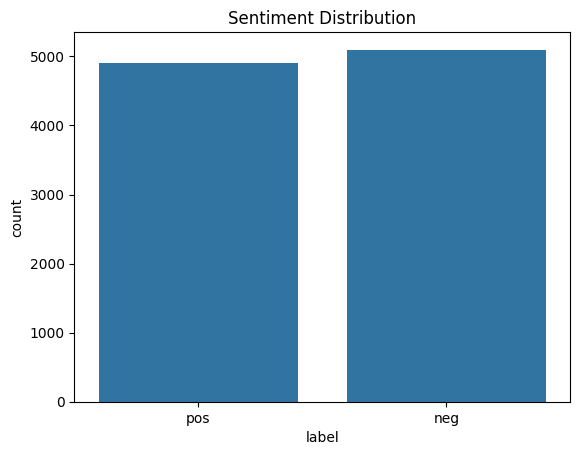

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=data['label'])
plt.title("Sentiment Distribution")
plt.show()


In [15]:
#pip install nltk

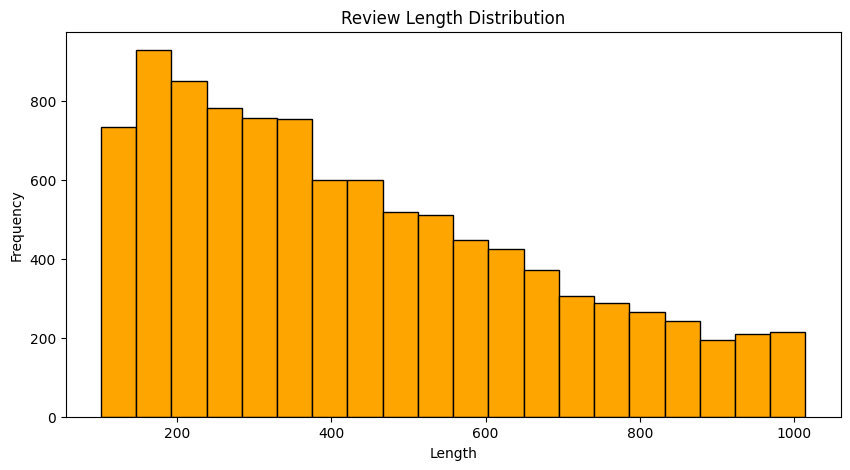

In [16]:
import matplotlib.pyplot as plt
data["length"] = data["review"].apply(len)

plt.figure(figsize=(10,5))
plt.hist(data["length"], bins=20, color="orange", edgecolor="black")
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [17]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemm = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'[^a-z\s]', '', text)             # remove punctuation & numbers
    words = text.split()
    words = [w for w in words if w not in stop_words] # remove stopwords
    words = [lemm.lemmatize(w) for w in words]        # lemmatization
    return " ".join(words)

data["cleaned_review"] = data["review"].apply(clean_text)

[nltk_data] Downloading package stopwords to C:\Users\Gururaj G
[nltk_data]     patil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Gururaj G
[nltk_data]     patil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Model Development:

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(max_features=3000, stop_words="english")
X = tfidf.fit_transform(data["review"])
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
log_reg = LogisticRegression(max_iter=300, solver="liblinear")
log_reg.fit(X_train, y_train)

# Linear SVM (best for text classification)
svm = LinearSVC()
svm.fit(X_train, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [22]:
pred_logreg = log_reg.predict(X_test)
pred_svm = svm.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score
acc_logreg = accuracy_score(y_test, pred_logreg)
acc_svm = accuracy_score(y_test, pred_svm)

In [24]:
print("\nModel Accuracy Scores:")
print("------------------------")
print("Logistic Regression:", acc_logreg)
print("Linear SVM:", acc_svm)


Model Accuracy Scores:
------------------------
Logistic Regression: 0.847
Linear SVM: 0.836


Validation:

In [25]:
from sklearn.metrics import  precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Precision:", precision_score(y_test, pred_logreg,zero_division=1))
print("Recall:", recall_score(y_test, pred_logreg,zero_division=1))
print("F1-score:", f1_score(y_test, pred_logreg,zero_division=1))

print("\nClassification Report:\n", classification_report(y_test, pred_logreg,zero_division=1))

Precision: 0.8404145077720208
Recall: 0.842159916926272
F1-score: 0.8412863070539419

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1037
           1       0.84      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [26]:
from sklearn.metrics import  precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Precision:", precision_score(y_test, pred_svm,zero_division=1))
print("Recall:", recall_score(y_test, pred_svm,zero_division=1))
print("F1-score:", f1_score(y_test, pred_svm,zero_division=1))

print("\nClassification Report:\n", classification_report(y_test, pred_svm,zero_division=1))

Precision: 0.8338590956887487
Recall: 0.8234683281412254
F1-score: 0.8286311389759665

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84      1037
           1       0.83      0.82      0.83       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



Cross-Validation

In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LogisticRegression(max_iter=500), X, y, cv=5)
print("Cross-Validation Accuracy:", scores)
print("Mean Accuracy:", scores.mean())


scores = cross_val_score(LinearSVC(), X, y, cv=5)
print("SVM CV Accuracy:", scores.mean())


Cross-Validation Accuracy: [0.857  0.826  0.8265 0.8315 0.84  ]
Mean Accuracy: 0.8362
SVM CV Accuracy: 0.8253


In [ ]:
#pip install wordcloud

Note: you may need to restart the kernel to use updated packages.Collecting wordcloud

     ---------------------------------------- 0.0/299.8 kB ? eta -:--:--
     - -------------------------------------- 10.2/299.8 kB ? eta -:--:--
     ------------- ---------------------- 112.6/299.8 kB 930.9 kB/s eta 0:00:01
     ------------------------------- ------ 245.8/299.8 kB 1.7 MB/s eta 0:00:01
     -------------------------------------- 299.8/299.8 kB 1.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


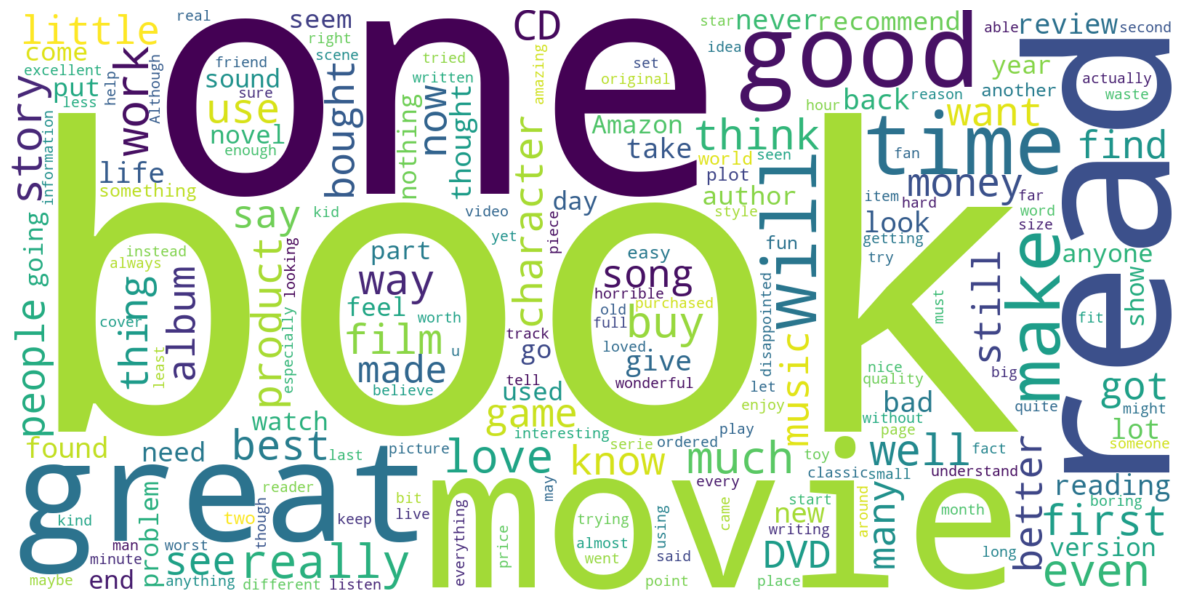

In [27]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load your file
data = pd.read_csv("amazonreviews.tsv", sep='\t')

# Combine all reviews into one string
text = " ".join(str(review) for review in data['review'])

# Generate the word cloud
wordcloud = WordCloud(width=1600, height=800,
                      background_color='white',
                      max_words=200).generate(text)

# Plot the word cloud
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()
